  Iris Flower Classification





## 1. Import Required Libraries



In [3]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Saving the model
import joblib

# Plot style settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Ensure consistent, reproducible results
RANDOM_STATE = 42

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load the Dataset



In [4]:
# Path to the dataset file
DATA_PATH = "IRIS.csv"

# Load the dataset into a pandas DataFrame
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")

Dataset loaded successfully.
Dataset shape: 150 rows and 5 columns


## 3. Display the First and Last Five Records



In [ ]:
# Display the first 5 records
print("First 5 records:")
df.head()

First 5 records:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
# Display the last 5 records
print("Last 5 records:")
df.tail()

Last 5 records:


,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


## 4. Explore the Dataset



### 4.1 Shape of the Dataset

In [ ]:
# Number of rows and columns
print(f"The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset contains 150 rows and 5 columns.


### 4.2 Data Types

In [ ]:
# Data types of each column
df.dtypes

,0
sepal_length,float64
sepal_width,float64
petal_length,float64
petal_width,float64
species,object


### 4.3 Missing Values

In [ ]:
# Check the number of missing values in each column
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


### 4.4 Statistical Summary

In [ ]:
# Statistical summary of the numeric features
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
# Number of samples per species (class balance)
df["species"].value_counts()

,count
species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


## 5. Data Cleaning



### 5.1 Check for Missing Values

In [ ]:
# Re-confirm there are no missing values
total_missing = df.isnull().sum().sum()
print(f"Total missing values in the dataset: {total_missing}")

Total missing values in the dataset: 0


### 5.2 Remove Duplicate Records (if any)

In [ ]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# Remove duplicates if they exist
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicate rows removed.")
else:
    print("No duplicate rows to remove.")

print(f"Dataset shape after cleaning: {df.shape}")

Number of duplicate rows found: 3
Duplicate rows removed.
Dataset shape after cleaning: (147, 5)


### 5.3 Verify Data Consistency

In [ ]:
# Verify that all species labels are consistent (no typos/extra spaces)
print("Unique species labels:", df["species"].unique())

# Verify that all numeric features have sensible (positive) values
print("\nMinimum values per feature:")
print(df.drop(columns=["species"]).min())

Unique species labels: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

Minimum values per feature:
sepal_length    4.3
sepal_width     2.0
petal_length    1.0
petal_width     0.1
dtype: float64


## 6. Exploratory Data Analysis (EDA)



### 6.1 Species Distribution

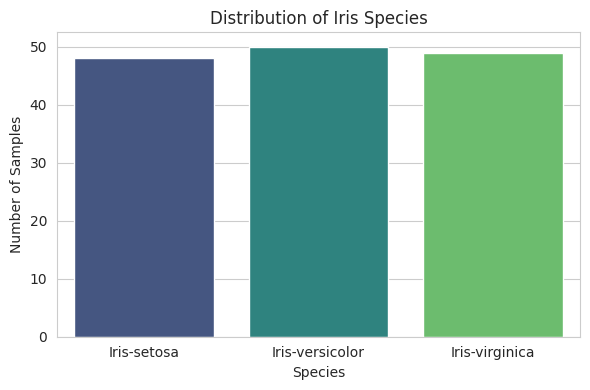

In [ ]:
# Bar plot showing the number of samples per species
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="species", hue="species", palette="viridis", legend=False)
plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

### 6.2 Pair Plot

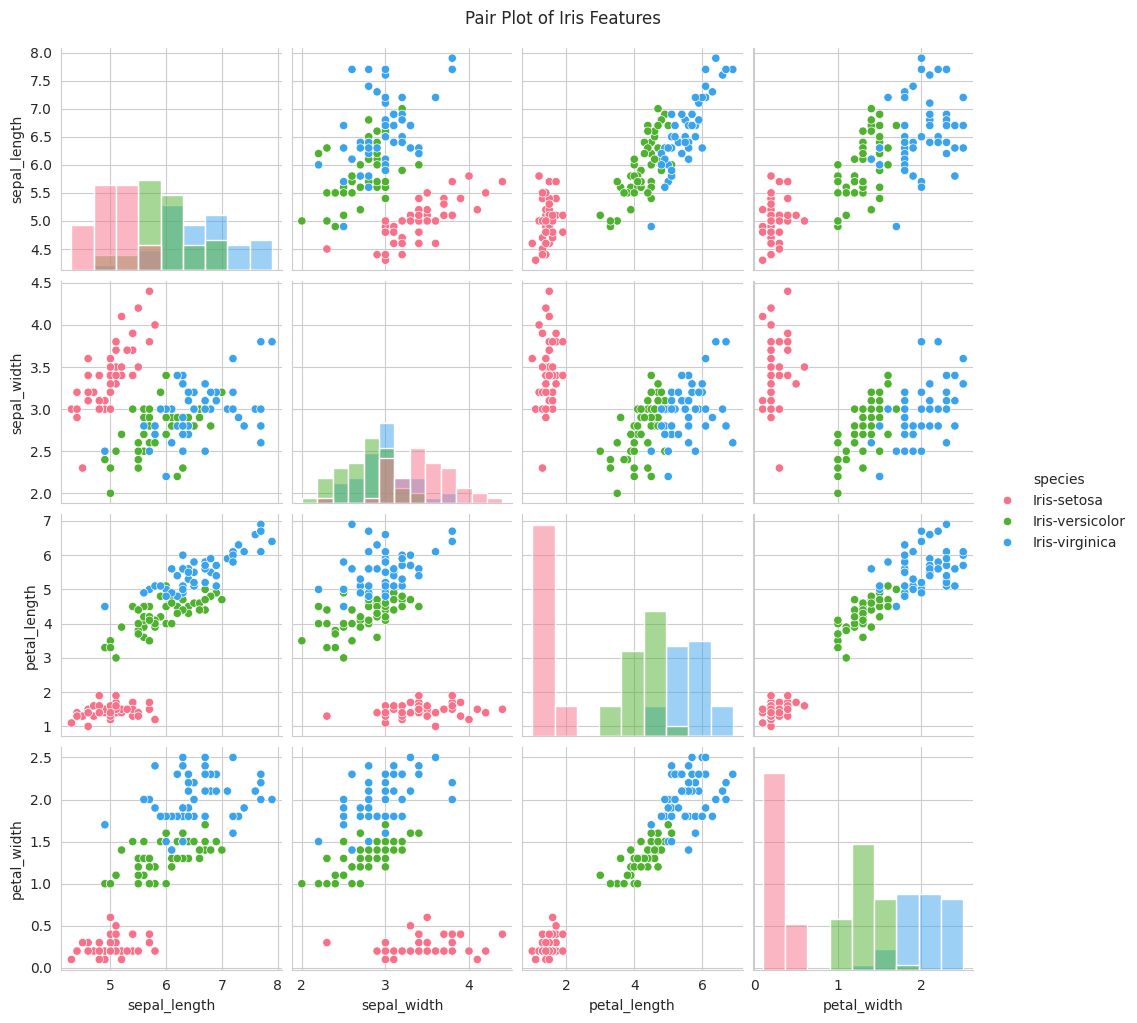

In [ ]:
# Pair plot to visualize relationships between all feature pairs, colored by species
sns.pairplot(df, hue="species", palette="husl", diag_kind="hist")
plt.suptitle("Pair Plot of Iris Features", y=1.02)
plt.show()

### 6.3 Correlation Heatmap

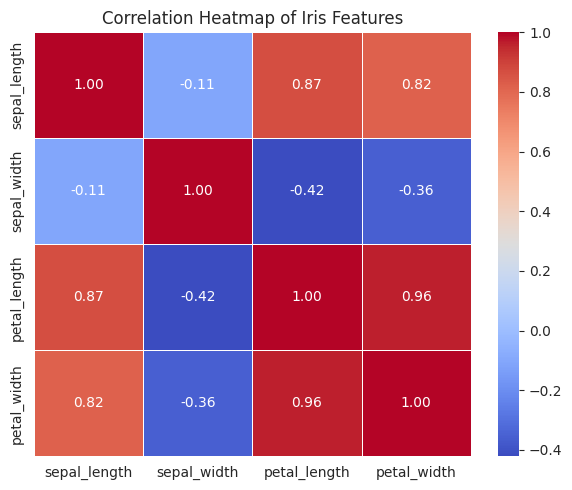

In [ ]:
# Correlation matrix of the numeric features
numeric_df = df.drop(columns=["species"])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Iris Features")
plt.tight_layout()
plt.show()

### 6.4 Histograms of All Features

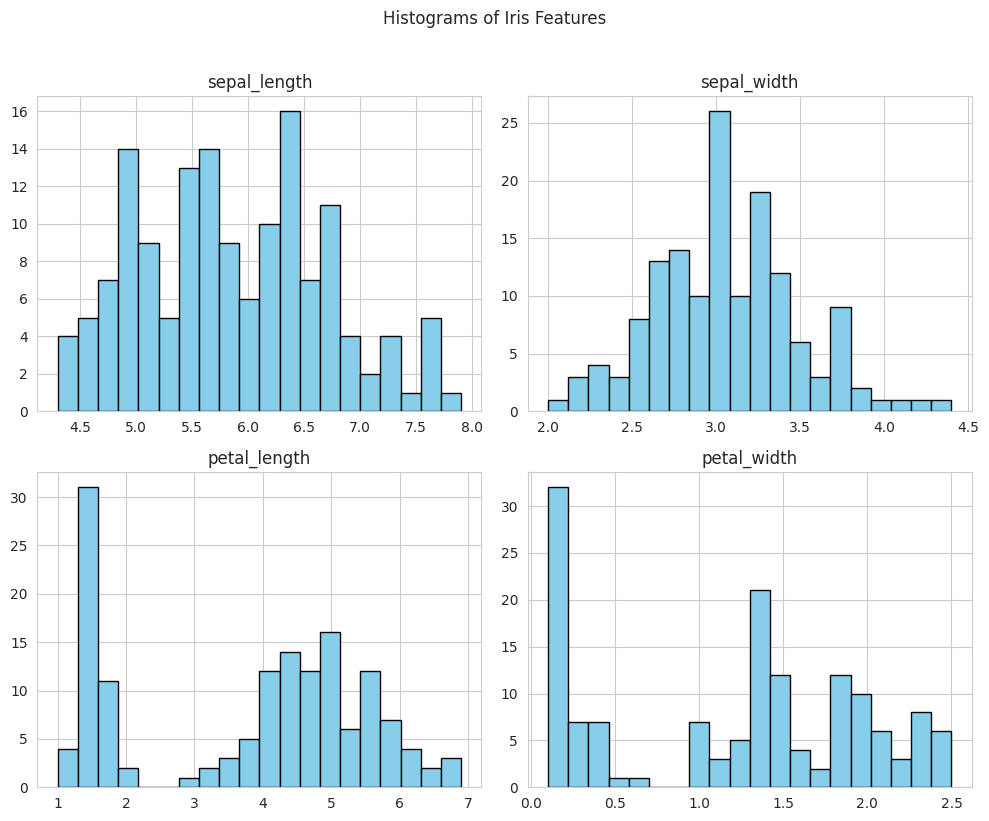

In [ ]:
# Histograms showing the distribution of each feature
df.drop(columns=["species"]).hist(bins=20, figsize=(10, 8), color="skyblue", edgecolor="black")
plt.suptitle("Histograms of Iris Features", y=1.02)
plt.tight_layout()
plt.show()

### 6.5 Box Plots for Feature Comparison

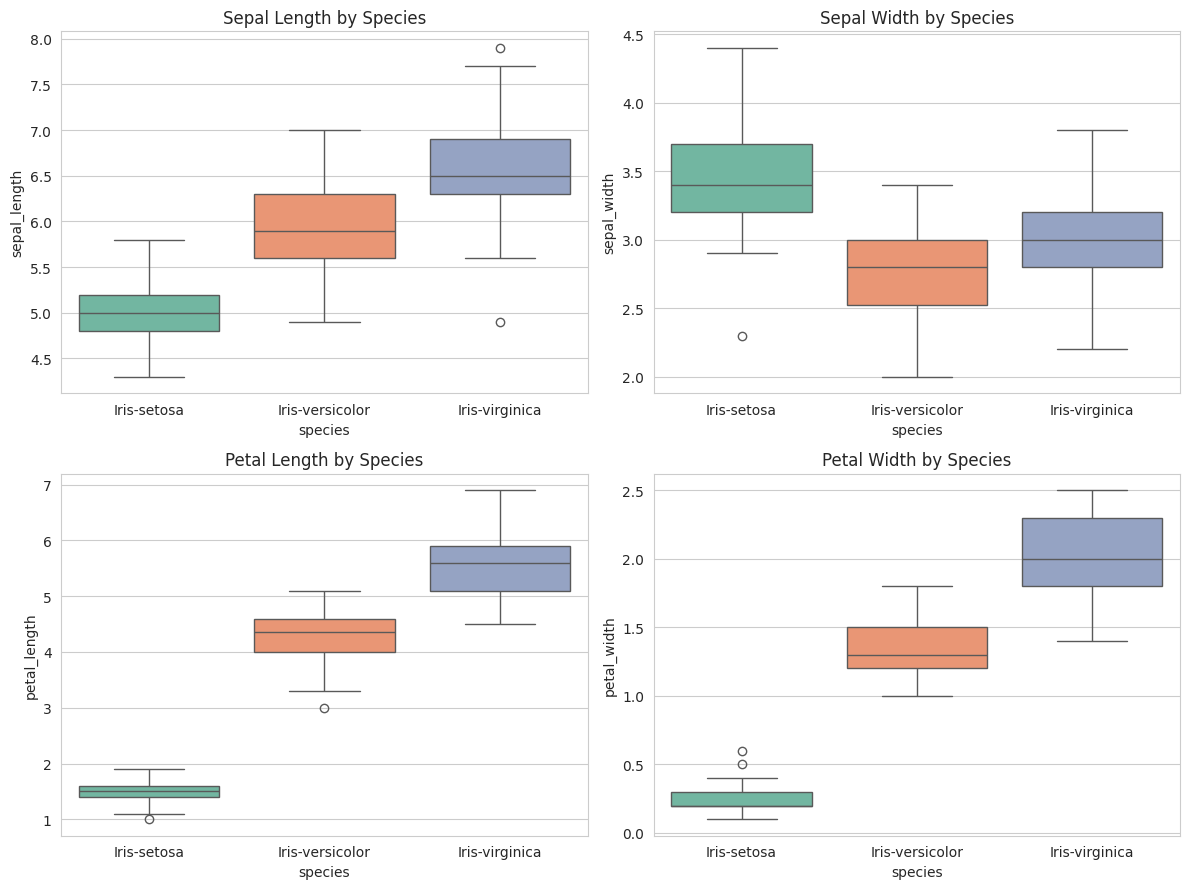

In [ ]:
# Box plots comparing each feature across the three species
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=df, x="species", y=feature, hue="species",
                palette="Set2", legend=False, ax=axes[i])
    axes[i].set_title(f"{feature.replace('_', ' ').title()} by Species")

plt.tight_layout()
plt.show()

## 7. Feature Selection



In [ ]:
# Define feature columns (X) and target column (y)
feature_columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

X = df[feature_columns]
y = df["species"]

# Encode the target labels (species) into numeric form: 0, 1, 2
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Features selected:", feature_columns)
print("Target classes:", list(label_encoder.classes_))
print("Encoded label mapping:",
      dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Features selected: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Target classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Encoded label mapping: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}


## 8. Split the Dataset into Training and Testing Sets



In [ ]:
# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size:  {X_test.shape[0]} samples")

Training set size: 117 samples
Testing set size:  30 samples


## 9. Train Multiple Classification Models



In [ ]:
# Dictionary to hold all model instances
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
}

# Dictionary to store trained models
trained_models = {}

# Train each model on the training data
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
K-Nearest Neighbors trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.


## 10. Compare All Models



In [ ]:
# Evaluate each model and store the results
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

# Convert results into a DataFrame for easy comparison
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,K-Nearest Neighbors,1.000000,1.000000,1.000000,1.000000
1,Logistic Regression,0.966667,0.969697,0.966667,0.966583
2,Random Forest,0.966667,0.969697,0.966667,0.966583
3,Decision Tree,0.933333,0.933333,0.933333,0.933333


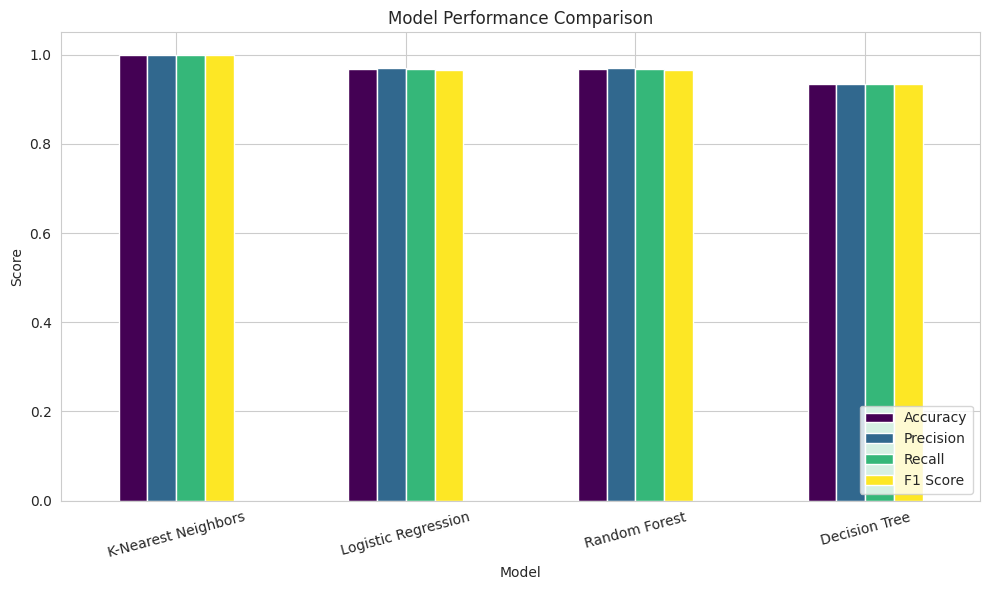

In [ ]:
# Visual comparison of model performance
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar", figsize=(10, 6), colormap="viridis"
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 11. Select the Best-Performing Model



In [ ]:
# Identify the best-performing model based on F1 Score
best_model_name = results_df.sort_values(by="F1 Score", ascending=False).iloc[0]["Model"]
best_model = trained_models[best_model_name]

print(f"Best-performing model: {best_model_name}")
print("\nPerformance summary:")
print(results_df[results_df["Model"] == best_model_name].to_string(index=False))

Best-performing model: K-Nearest Neighbors

Performance summary:
              Model  Accuracy  Precision  Recall  F1 Score
K-Nearest Neighbors       1.0        1.0     1.0       1.0


## 12. Predict the Species of Unseen Iris Flower Samples



In [ ]:
# Create a few new, unseen samples (sepal_length, sepal_width, petal_length, petal_width)
new_samples = pd.DataFrame({
    "sepal_length": [5.0, 6.3, 6.7],
    "sepal_width":  [3.4, 2.8, 3.1],
    "petal_length": [1.5, 4.9, 5.6],
    "petal_width":  [0.2, 1.5, 2.4]
})

# Predict using the best model
predicted_labels = best_model.predict(new_samples)
predicted_species = label_encoder.inverse_transform(predicted_labels)

# Display results
new_samples_with_predictions = new_samples.copy()
new_samples_with_predictions["Predicted Species"] = predicted_species
new_samples_with_predictions

,sepal_length,sepal_width,petal_length,petal_width,Predicted Species
0,5.0,3.4,1.5,0.2,Iris-setosa
1,6.3,2.8,4.9,1.5,Iris-virginica
2,6.7,3.1,5.6,2.4,Iris-virginica


## 13. Display the Confusion Matrix



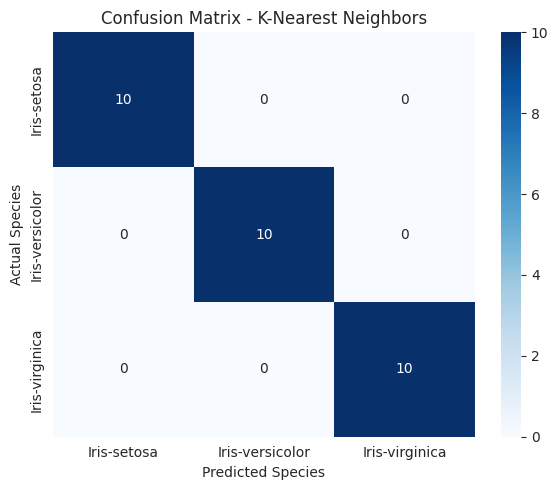

In [ ]:
# Generate predictions on the test set using the best model
y_pred_best = best_model.predict(X_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.tight_layout()
plt.show()

## 14. Display the Classification Report



In [ ]:
# Generate and print the detailed classification report
report = classification_report(y_test, y_pred_best, target_names=label_encoder.classes_)
print(f"Classification Report - {best_model_name}\n")
print(report)

Classification Report - K-Nearest Neighbors

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



## 15. Plot Feature Importance (if supported by the model)



In [ ]:
# Check if the best model supports feature importance
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=feature_columns)
    importances = importances.sort_values(ascending=False)

    plt.figure(figsize=(7, 5))
    sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
                palette="viridis", legend=False)
    plt.title(f"Feature Importance - {best_model_name}")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    print(importances)
else:
    print(f"{best_model_name} does not support feature importance "
          f"(this is expected for models like Logistic Regression or KNN).")

K-Nearest Neighbors does not support feature importance (this is expected for models like Logistic Regression or KNN).


## 16. Save the Trained Model Using Joblib



In [ ]:
# Save the best model to a .pkl file
model_filename = "iris_best_model.pkl"
joblib.dump(best_model, model_filename)

# Save the label encoder as well, since it's needed to decode predictions
encoder_filename = "iris_label_encoder.pkl"
joblib.dump(label_encoder, encoder_filename)

print(f"Model saved as: {model_filename}")
print(f"Label encoder saved as: {encoder_filename}")

Model saved as: iris_best_model.pkl
Label encoder saved as: iris_label_encoder.pkl


In [ ]:
# Demonstration: reload the saved model and verify it works correctly
loaded_model = joblib.load(model_filename)
loaded_encoder = joblib.load(encoder_filename)

sample_prediction = loaded_model.predict(new_samples)
decoded_prediction = loaded_encoder.inverse_transform(sample_prediction)

print("Predictions from the reloaded model:", list(decoded_prediction))

Predictions from the reloaded model: ['Iris-setosa', 'Iris-virginica', 'Iris-virginica']
